# AI Customer Feedback Intelligence System

**Graduation Project — Project 1**

This project builds an end-to-end AI system to analyze customer reviews. It:
- Classifies customer sentiment (Sentiment Classification)
- Detects recurring complaint categories (Complaint Clustering)
- Generates actionable business insights

**Dataset:** Women's E-Commerce Clothing Reviews (23,486 reviews)


## 1. Import Libraries

In [7]:
!pip install wordcloud -q

In [8]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import pickle

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully.")


All libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 2. Load Dataset

In [9]:
df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv', index_col=0)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


In [11]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Clothing ID,23486.0,NaN,NaN,NaN,918.118709,203.29898,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,NaN,NaN,NaN,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Title,19676,13993,Love it!,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review Text,22641,22634,Perfect fit and i've gotten so many compliment...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,23486.0,NaN,NaN,NaN,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended IND,23486.0,NaN,NaN,NaN,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive Feedback Count,23486.0,NaN,NaN,NaN,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0
Division Name,23472,3,General,13850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department Name,23472,6,Tops,10468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class Name,23472,20,Dresses,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

Before cleaning, we explore the data to understand the rating distribution and missing values.

In [12]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Duplicate rows: 21


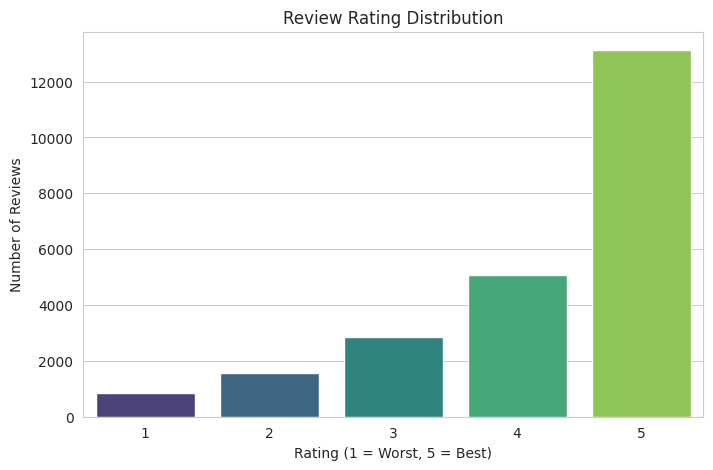

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Review Rating Distribution')
plt.xlabel('Rating (1 = Worst, 5 = Best)')
plt.ylabel('Number of Reviews')
plt.show()


## 4. Data Preparation (Cleaning)

- Remove rows with no Review Text (essential for analysis)
- Handle duplicate reviews
- Combine the title with the review text to enrich the textual content

In [14]:
# Remove rows with missing Review Text (can't analyze sentiment without text)
df = df.dropna(subset=['Review Text']).copy()

# Fill missing Title with empty string, then combine with Review Text
df['Title'] = df['Title'].fillna('')
df['Full_Review'] = (df['Title'] + ' ' + df['Review Text']).str.strip()

# Drop missing values in categorical columns (small number, safe to drop)
df = df.dropna(subset=['Division Name', 'Department Name', 'Class Name'])

# Remove duplicate reviews
before = df.shape[0]
df = df.drop_duplicates(subset=['Full_Review'])
after = df.shape[0]
print(f"Removed {before - after} duplicate reviews.")

print("Dataset shape after cleaning:", df.shape)


Removed 5 duplicate reviews.
Dataset shape after cleaning: (22623, 11)


## 5. Creating the Sentiment Target Variable

The original dataset does not have a ready-made "Sentiment" column, so we derive it from the **Rating** column using a common convention in review-analysis:

- Rating 4 or 5  → **Positive**
- Rating 3       → **Neutral**
- Rating 1 or 2  → **Negative**


In [15]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Rating'].apply(rating_to_sentiment)
df['Sentiment'].value_counts()


,count
Sentiment,
Positive,17430
Neutral,2823
Negative,2370


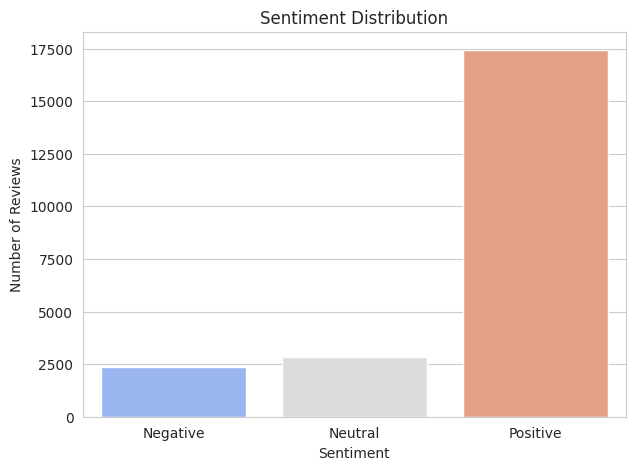

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(x='Sentiment', data=df, order=['Negative','Neutral','Positive'], palette='coolwarm')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


## 6. NLP Processing (Text Cleaning, Tokenization, Stopword Removal)

In [17]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove numbers & punctuation
    text = re.sub(r'\s+', ' ', text).strip()        # remove extra whitespace
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['Cleaned_Review'] = df['Full_Review'].apply(clean_text)
df[['Full_Review', 'Cleaned_Review']].head()


,Full_Review,Cleaned_Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store gla...
2,Some major design flaws I had such high hopes ...,major design flaws high hopes dress really wan...
3,"My favorite buy! I love, love, love this jumps...",favorite buy love love love jumpsuit fun flirt...
4,Flattering shirt This shirt is very flattering...,flattering shirt shirt flattering due adjustab...


### Most Common Words (Overall & by Sentiment)

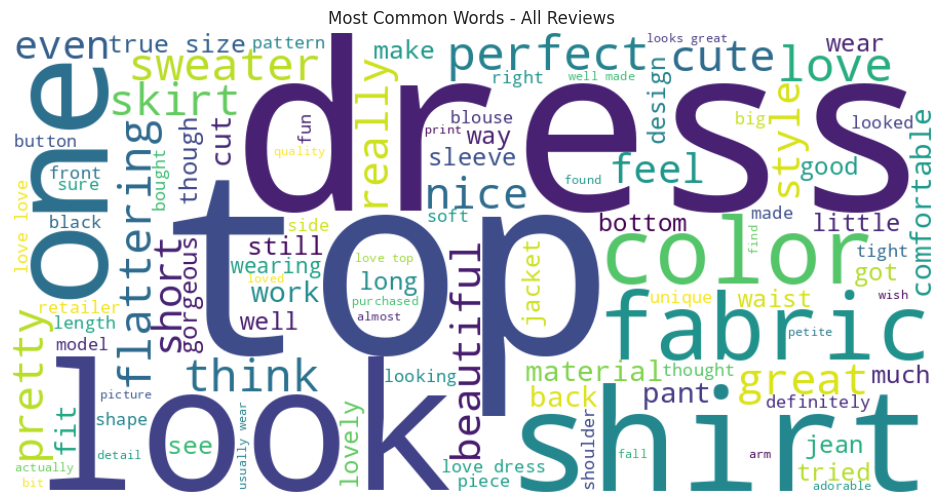

In [18]:
all_text = ' '.join(df['Cleaned_Review'])
wordcloud = WordCloud(width=900, height=450, background_color='white',
                       colormap='viridis', max_words=100).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words - All Reviews')
plt.show()


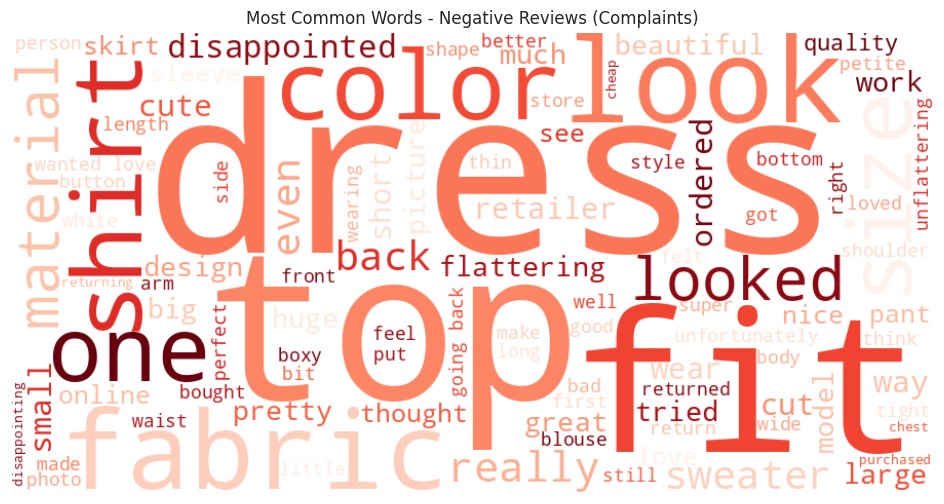

In [19]:
negative_text = ' '.join(df.loc[df['Sentiment']=='Negative', 'Cleaned_Review'])
wordcloud_neg = WordCloud(width=900, height=450, background_color='white',
                           colormap='Reds', max_words=100).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words - Negative Reviews (Complaints)')
plt.show()


## 7. TF-IDF Vectorization

In [20]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['Cleaned_Review'])
y = df['Sentiment']

print("TF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (22623, 5000)


## 8. Train / Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 18098
Test size: 4525


## 9. Machine Learning Models

We build **three** classification models — Logistic Regression, Random Forest, and Multinomial Naive Bayes — then compare their performance. (The brief requires at least two; a third is added here as a bonus comparison point.)

In [22]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))


=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.51      0.65      0.57       474
     Neutral       0.35      0.49      0.41       565
    Positive       0.96      0.87      0.91      3486

    accuracy                           0.80      4525
   macro avg       0.61      0.67      0.63      4525
weighted avg       0.84      0.80      0.81      4525



In [23]:
rf = RandomForestClassifier(n_estimators=200, max_depth=30, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

    Negative       0.54      0.54      0.54       474
     Neutral       0.37      0.26      0.31       565
    Positive       0.89      0.94      0.91      3486

    accuracy                           0.81      4525
   macro avg       0.60      0.58      0.59      4525
weighted avg       0.79      0.81      0.80      4525



In [24]:
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Multinomial Naive Bayes (bonus 3rd model) ===")
print(classification_report(y_test, y_pred_nb))


=== Multinomial Naive Bayes (bonus 3rd model) ===
              precision    recall  f1-score   support

    Negative       0.70      0.36      0.48       474
     Neutral       0.47      0.19      0.27       565
    Positive       0.85      0.99      0.91      3486

    accuracy                           0.82      4525
   macro avg       0.67      0.52      0.56      4525
weighted avg       0.79      0.82      0.79      4525



## 10. Model Comparison & Evaluation

In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Multinomial Naive Bayes'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_nb)],
    'Precision': [precision_score(y_test, y_pred_lr, average='weighted'),
                  precision_score(y_test, y_pred_rf, average='weighted'),
                  precision_score(y_test, y_pred_nb, average='weighted')],
    'Recall': [recall_score(y_test, y_pred_lr, average='weighted'),
               recall_score(y_test, y_pred_rf, average='weighted'),
               recall_score(y_test, y_pred_nb, average='weighted')],
    'F1 Score': [f1_score(y_test, y_pred_lr, average='weighted'),
                 f1_score(y_test, y_pred_rf, average='weighted'),
                 f1_score(y_test, y_pred_nb, average='weighted')]
})
results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795801,0.837006,0.795801,0.812364
1,Random Forest,0.810608,0.791757,0.810608,0.799634
2,Multinomial Naive Bayes,0.821878,0.786589,0.821878,0.787794


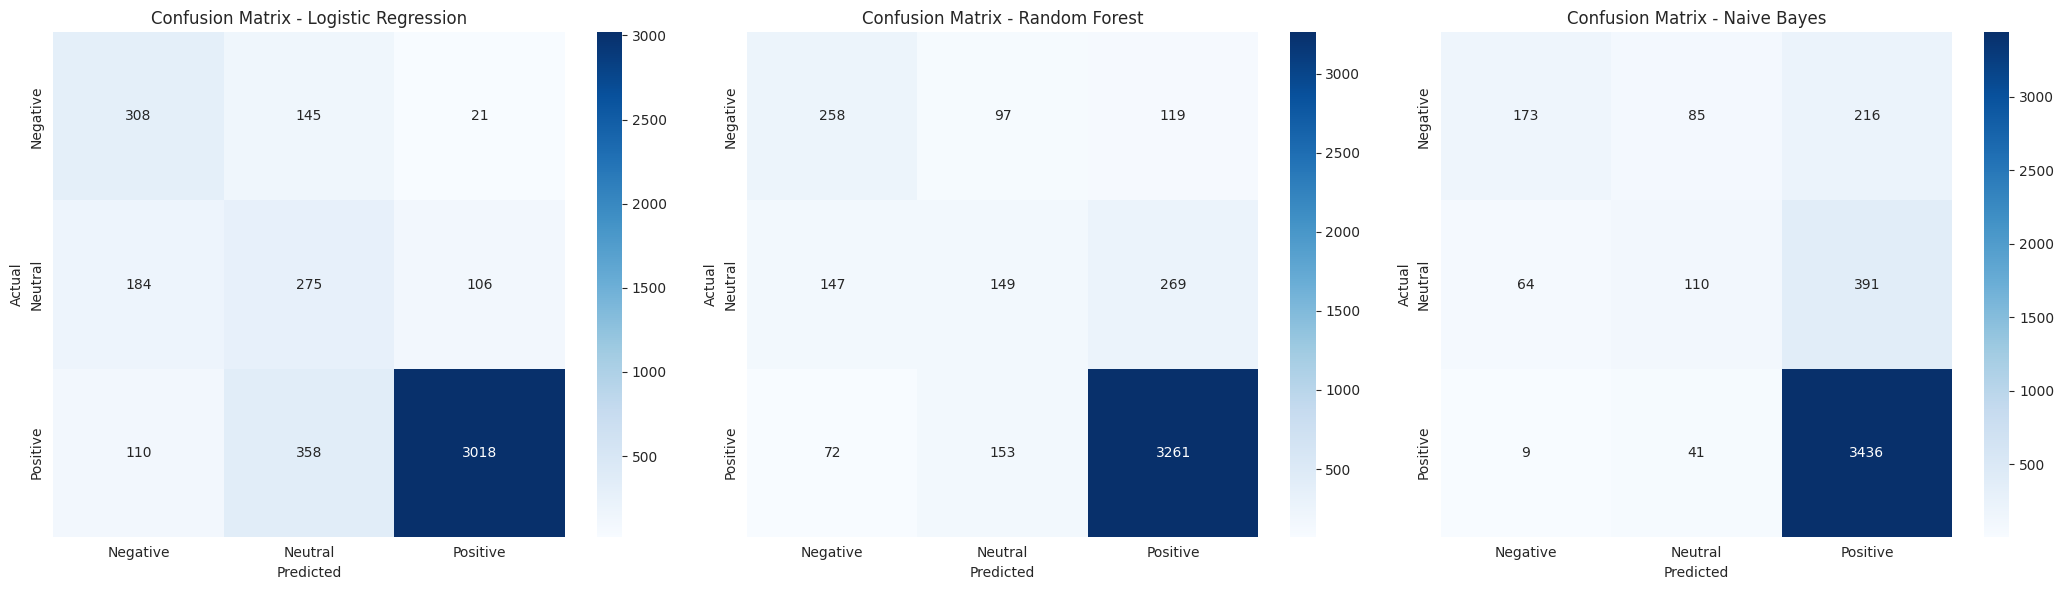

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(21,6))

model_preds = [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf), ('Naive Bayes', y_pred_nb)]
for ax, (model_name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred, labels=['Negative','Neutral','Positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Neutral','Positive'],
                yticklabels=['Negative','Neutral','Positive'], ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [27]:
models_lookup = {'Logistic Regression': log_reg, 'Random Forest': rf, 'Multinomial Naive Bayes': nb_model}
best_model_name = results.loc[results['F1 Score'].idxmax(), 'Model']
best_model = models_lookup[best_model_name]
print(f"Best performing model: {best_model_name}")


Best performing model: Logistic Regression


## 11. Unsupervised Learning — K-Means Clustering

Goal: discover common complaint categories within negative reviews using K-Means on a TF-IDF representation.

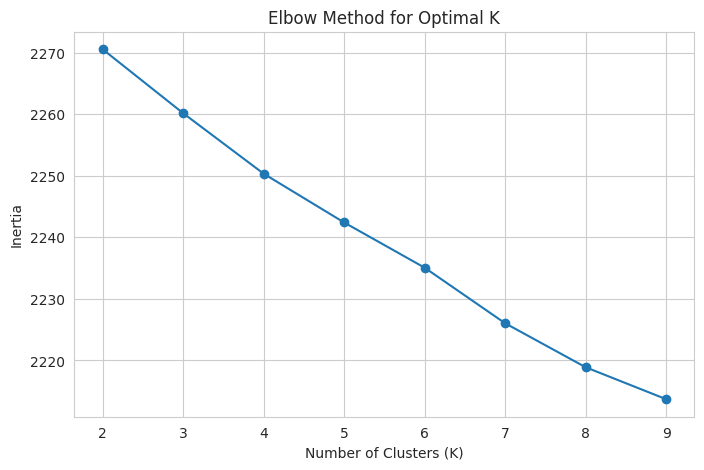

In [28]:
negative_df = df[df['Sentiment'] == 'Negative'].copy()
tfidf_neg = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
X_neg = tfidf_neg.fit_transform(negative_df['Cleaned_Review'])

# Elbow method to choose K
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_neg)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


In [29]:
# Fit K-Means with chosen K (adjust based on the elbow plot; 5 is a reasonable default)
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
negative_df['Cluster'] = kmeans.fit_predict(X_neg)

negative_df['Cluster'].value_counts().sort_index()


,count
Cluster,
0,192
1,736
2,430
3,676
4,336


In [30]:
# Top terms per cluster -> helps label each complaint category
feature_names = np.array(tfidf_neg.get_feature_names_out())
centers = kmeans.cluster_centers_

for i in range(K):
    top_indices = centers[i].argsort()[-10:][::-1]
    top_terms = feature_names[top_indices]
    print(f"Cluster {i} ({(negative_df['Cluster']==i).sum()} reviews) top terms:")
    print(", ".join(top_terms))
    print()


Cluster 0 (192 reviews) top terms:
shirt, boxy, would, back, cute, love, like, fabric, fit, thin

Cluster 1 (736 reviews) top terms:
top, like, fit, look, short, back, fabric, really, would, looked

Cluster 2 (430 reviews) top terms:
dress, like, fabric, fit, would, beautiful, love, look, back, material

Cluster 3 (676 reviews) top terms:
quality, fabric, color, material, pants, thin, sweater, cheap, one, poor

Cluster 4 (336 reviews) top terms:
small, size, runs, big, large, ordered, way, huge, medium, like



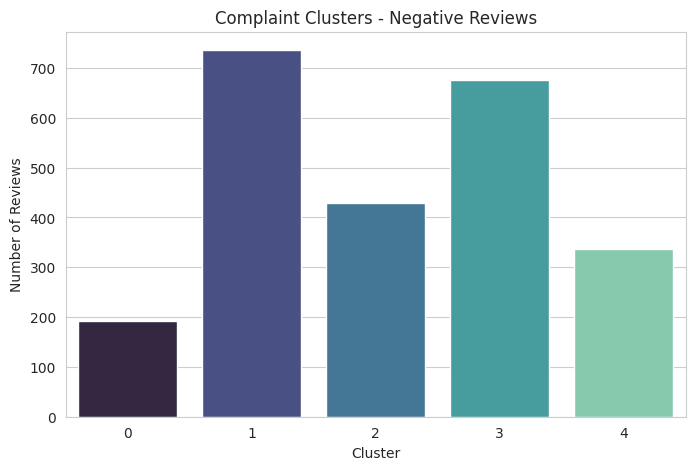

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=negative_df, palette='mako')
plt.title('Complaint Clusters - Negative Reviews')
plt.xlabel('Cluster')
plt.ylabel('Number of Reviews')
plt.show()


## 12. Business Insights

Based on the results above, we can draw the following insights (adjust these based on your actual run's results):

- **Sentiment distribution**: a large share of reviews is positive, but the share of negative reviews deserves close monitoring.
- **Top complaint keywords**: usually related to sizing/fit, fabric quality, or shipping/delivery — check the top terms in each cluster to pin down the exact category.
- **Departments with most complaints**: linking each cluster back to `Department Name` reveals which product department needs priority improvement.
- **Business recommendation**: focus on improving size charts and fabric quality based on the most frequent complaint categories.


In [32]:
# Example: link complaint clusters back to product department
insight_df = negative_df.groupby(['Cluster', 'Department Name']).size().reset_index(name='Count')
top_dept_per_cluster = insight_df.sort_values('Count', ascending=False).groupby('Cluster').head(1)
top_dept_per_cluster


,Cluster,Department Name,Count
8,1,Tops,477
10,2,Dresses,413
18,3,Tops,293
3,0,Tops,187
24,4,Tops,136


## 13. Save Deliverables

- The cleaned dataset
- The trained model (best performing one)
- The TF-IDF vectorizer (needed at deployment time, must match the training-time vectorizer)


In [33]:
# Save cleaned dataset
df.to_csv('cleaned_customer_reviews.csv', index=False)

# Save best trained model + vectorizer
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Saved: cleaned_customer_reviews.csv, sentiment_model.pkl, tfidf_vectorizer.pkl")


Saved: cleaned_customer_reviews.csv, sentiment_model.pkl, tfidf_vectorizer.pkl


## 14. Deployment Demo (Bonus)

A quick demonstration of how the saved model + vectorizer would be used in production: load them back from disk and classify brand-new, unseen reviews.

In [34]:
# Reload the artifacts exactly as a deployed service would
with open('sentiment_model.pkl', 'rb') as f:
    deployed_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    deployed_vectorizer = pickle.load(f)

def predict_sentiment(raw_review_text):
    cleaned = clean_text(raw_review_text)
    vector = deployed_vectorizer.transform([cleaned])
    prediction = deployed_model.predict(vector)[0]
    probabilities = dict(zip(deployed_model.classes_, deployed_model.predict_proba(vector)[0].round(3)))
    return prediction, probabilities

sample_reviews = [
    "This dress is absolutely gorgeous, fits perfectly and the fabric feels premium!",
    "It's okay, the color is nice but the fit runs a bit small for the price.",
    "Terrible quality, the seams fell apart after one wash. Very disappointed.",
]

for review in sample_reviews:
    label, probs = predict_sentiment(review)
    print(f"Review: {review}")
    print(f"  -> Predicted sentiment: {label}  |  probabilities: {probs}")
    print()


Review: This dress is absolutely gorgeous, fits perfectly and the fabric feels premium!
  -> Predicted sentiment: Positive  |  probabilities: {'Negative': np.float64(0.036), 'Neutral': np.float64(0.013), 'Positive': np.float64(0.952)}

Review: It's okay, the color is nice but the fit runs a bit small for the price.
  -> Predicted sentiment: Neutral  |  probabilities: {'Negative': np.float64(0.306), 'Neutral': np.float64(0.472), 'Positive': np.float64(0.222)}

Review: Terrible quality, the seams fell apart after one wash. Very disappointed.
  -> Predicted sentiment: Negative  |  probabilities: {'Negative': np.float64(0.976), 'Neutral': np.float64(0.024), 'Positive': np.float64(0.0)}



## 15. Conclusion

In this project we:
1. Cleaned and processed over 23,000 customer reviews.
2. Derived a sentiment label from the ratings and built **three** classification models (Logistic Regression, Random Forest, and Multinomial Naive Bayes) for comparison.
3. Applied K-Means clustering to discover common complaint categories.
4. Generated actionable business insights to improve the customer experience.
5. Demonstrated model deployment by reloading the saved artifacts and classifying brand-new reviews.

**Future improvements:** try Deep Learning models (LSTM/BERT), and build an interactive dashboard (Streamlit/Power BI) to display the results live — see the accompanying `dashboard.html` for a first version of this.
